In [41]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

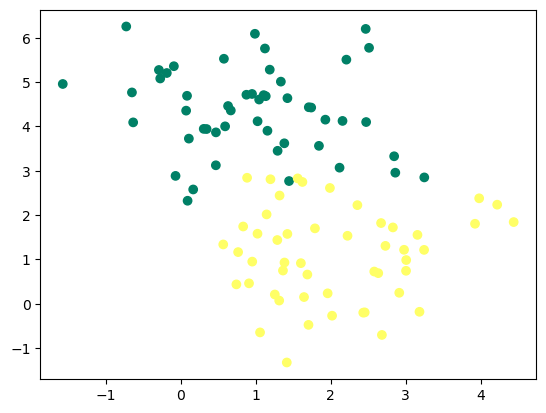

In [42]:
X, y= make_blobs(n_samples=100, n_features=2, centers=2, random_state=0)
y = np.reshape(y, (X.shape[0], 1))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='summer')
plt.show()

In [43]:
def initialisation(X):
    W = np.random.randn(X.shape[1], 1)
    b = np.random.randn(1)
    return (W, b)

In [44]:
def model(X, W, b):
    assert X.shape[1] == W.shape[0]
    Z = X.dot(W) + b
    A = 1 / (1 + np.exp(-Z))
    return A

In [45]:
def log_loss(y, A):
    assert A.shape[0] == y.shape[0] and A.shape[1] == y.shape[1]
    return - np.sum(y*np.log(A) + (1-y)*np.log(1-A)) / y.shape[0]

In [46]:
def gradients(A, X, y):
    assert A.shape[0] == y.shape[0] and A.shape[1] == y.shape[1] and X.shape[0] == y.shape[0]
    dW = X.T.dot(A-y) / y.shape[0]
    db = np.sum(A-y) / y.shape[0]
    return (dW, db)

In [47]:
def update(dW, db, W, b, alpha):
    W = W - alpha*dW
    b = b - alpha*db
    return (W, b)

In [48]:
def predict(X, W, b):
    A = model(X, W, b)
    return A >= 0.5

In [49]:
def neuron(X, y, learning_rate=0.1, n_iterations=10000):
    W, b = initialisation(X)
    loss = []
    for i in range(n_iterations):
        A = model(X, W, b)
        loss.append(log_loss(y, A))
        dW, db = gradients(A, X, y)
        W, b = update(dW, db, W, b, learning_rate)

    plt.plot(np.arange(0, len(loss)), loss)
    plt.show()
    return (W, b)

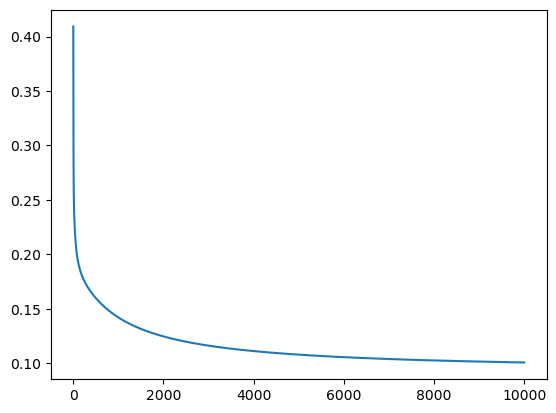

In [50]:
W, b = neuron(X, y)
# Graph of the loss function